# SAGITTARIUS II

Discovered by [Laevens et al. 2015](https://iopscience.iop.org/article/10.1088/0004-637X/813/1/44) in Pan-STARRS1 3$\Pi$ survey, Sagittarius II (SgrII) is an ultra-faint system at a heliocentric distance of $73$ kpc ($M_V \approx -5.7$ mag, $r_h \approx 37$ pc). 
Occupying a peculiar position in the size-luminosity plane, the dual nature of SgrII -- whether a disrupting dwarf galaxy or an unusually extended star cluster -- remains debated. 
Its position along the trailing arm of the Sgr stream suggests it was originally a satellite of the Sgr dSph galaxy. 
[Joo et al. 2019](https://iopscience.iop.org/article/10.3847/1538-4357/ab11ca) identified six RRLs via optical time-series photometry and $G$-band data from Gaia DR2, with five located within $3 r_h$ confirming high membership probability. 
Its compact morphology and metal-poor content make SgrII a crucial transitional object and a tracer of early accretion events in the MW halo.

## Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astropy.io import ascii, fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.io.votable import parse, parse_single_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

from shapely.geometry import Point, Polygon

import csv

import pandas as pd

from scipy.stats import norm, lognorm, expon, gamma

from statistics import mode

import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import warnings
warnings.filterwarnings('ignore')

## Joint Proper Motions Histograms

In [2]:
def scatter_hist(x, y, x_rr, y_rr, ax, ax_histx, ax_histy, center_pm, err_pm):
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    
    ax.set_xlim(-20,20)
    ax.set_ylim(-20,20)
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
    ax.set_ylabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
    
    ax.scatter(x, y, marker='o', s=10, label=r'Sources in 6$r_h$', color='lightgrey')
    ax.scatter(x_rr, y_rr, marker='o', edgecolor='k', s=100, label=r'RR Lyrae Variables', color='gold', zorder=2)

    ax_histx.set_ylim(0,1)
    ax_histy.set_xlim(0,1)
    ax_histx.tick_params(labelsize=14)
    ax_histy.tick_params(labelsize=14)
    ax_histx.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histy.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histx.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    ax_histy.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    
    ax_histx.hist(x, bins=len(x), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$')
    ax_histy.hist(y, bins=len(y), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$', orientation='horizontal')
    
    ax_histx.hist(x_rr, bins=len(x_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables')
    ax_histy.hist(y_rr, bins=len(y_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables', orientation='horizontal')
    
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='white', linewidth=5)
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='white', linewidth=5)
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='deepskyblue', linewidth=2, label=r'$\mu_{pmra}$=' + '{:.3f}'.format(center_pm[0]) + '\n' + r'$\sigma_{pmra}$=' + '{:.3f}'.format(err_pm[0]))
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='deepskyblue', linewidth=2, label=r'$\mu_{pmdec}$=' + '{:.3f}'.format(center_pm[1]) + '\n' + r'$\sigma_{pmdec}$=' + '{:.3f}'.format(err_pm[1]))
    
    ax_histx.axvspan(center_pm[0] - 3*err_pm[0], center_pm[0] + 3*err_pm[0], alpha=0.1, color='cyan', zorder=1)
    ax_histy.axhspan(center_pm[1] - 3*err_pm[1], center_pm[1] + 3*err_pm[1], alpha=0.1, color='cyan', zorder=1)
    
    ax_histx.legend(loc=1, fontsize=14, framealpha=0.95)
    ax_histy.legend(loc=1, fontsize=14, framealpha=0.95)

## Wesenheit Relation for RR Lyrae ([Garofalo et al. 2022](https://doi.org/10.1093/mnras/stac735))

In [3]:
## Garofalo et al. 2022, pag. 14

def pw(period, fe, mu0) : # 'period' in log10
    pw_line = - 2.49 * period + 0.14 * fe - 0.88 + mu0

    return pw_line


## Garofalo et al. 2022, pag. 12-13

def wesen(g, bp, rp) :
    w = g - 1.922 * (bp - rp)
    
    return w


## Error Propagation

def wesen_err(g_err, bp_err, rp_err) :
    w_err = g_err + 1.922 * (bp_err + rp_err)
    
    return w_err

## Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
##### NOTE on errors: 
If using "int_g_average" for $G$-band magnitude, we already have "int_g_average_error"; if using "phot_g_mean_mag", we use the flux-derived error ("phot_g_err"). For $G_{BP}$ and $G_{RP}$, we exclusively use "phot_*_mean_mag" as they are more reliable.

In [4]:
def mag_err(flux, flux_err) :
    mag_error = 1.0857 * flux_err / flux
    
    return mag_error

## Data download

In [5]:
data = pd.read_csv('Data/SagittariusII_3.csv', header=0)
#cu5

data_rr = pd.read_csv('Data/vari_rrlyrae.csv', header=0, low_memory=False)
#cu7=coordination unit of variables

data_class = pd.read_csv('Data/vari_classifier_result.csv', header=0)

### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [6]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'SagittariusII']

print(vivas)

          galaxy        ra     dec  M_V  distance  fe_h  r_h  epsilon     PA  \
2  SagittariusII  298.1663 -22.065 -5.7      73.1 -2.28  1.7      0.0  103.0   

   r_t  N_RR  N_RR.1  N_(RR)  N_RR.2 Ref  Ref.1 Ref.2  
2  NaN   5.0       5       1       6   3    3.0    23  


### Known RR Lyrae  in [Tau et al. 2024](https://iopscience.iop.org/article/10.3847/1538-3881/ad1509) (table 2)

In [7]:
tau_table = pd.read_csv('Papers_tables/Tau_table2.csv', header=0)

tau = tau_table[tau_table['galaxy'] == 'SagittariusII']

tau_complete = tau

print('RR Lyrae in Tau et al. (2024): ' + str(len(tau_complete)))

#tau_complete.to_csv('Output/SagittariusII/SagittariusII_rr_Tau_complete.csv', index=False)


# Conversion to integers

tau['source_id'] = tau['source_id'].astype(int)

# From Tau, we keep only the 'source_id' column and merge it with the Gaia Archive data

tau = tau[['source_id']]

#print(tau)


# Merging with vari_classifier

tau = tau.merge(data_class, on='source_id')


# Merging with vari_rrlyrae

tau_rr = tau.merge(data_rr)
print(tau_rr['source_id'])


print('Correspondence with Gaia Variable Classifier: ' + str(len(tau)))
print('Correspondence with Gaia RR Lyrae: ' + str(len(tau_rr)))

# Tau RR Lyrae + those that do not match the Gaia catalogue
# NOTE: These are all of Tau RR Lyrae excluding the one without a Gaia source_id, 
# so the sample includes both vari_rrlyrae and vari_classifier entries

#tau.to_csv('Output/SagittariusII/SagittariusII_rr_Tau.csv', index=False)


RR Lyrae in Tau et al. (2024): 5
0    6864048408410304896
1    6864423994704275200
2    6864422757758521984
3    6864422993976659968
4    6865195302117134336
Name: source_id, dtype: int64
Correspondence with Gaia Variable Classifier: 5
Correspondence with Gaia RR Lyrae: 5


### Spectroscopic members ([Zaremba et al. 2025](https://iopscience.iop.org/article/10.3847/1538-4357/add5f9), table 1)

In [8]:
memb_table = pd.read_csv('Papers_tables/Zaremba_table1.csv', header=0)

memb_complete = memb_table[memb_table['galaxy'] == 'SgrII']

print('Spectroscopic Members: ' + str(len(memb_complete)))


## Correspondence with Gaia (gaiadr3.gaia_source)

memb_table_cross = pd.read_csv('Papers_tables/Zaremba_table1_SgrII_crossmatch.csv', header=0)

memb = memb_table_cross[memb_table_cross['galaxy'] == 'SgrII']

memb['source_id'] = memb['source_id'].astype(int)


## Mask for Sources which are not 'NaN' in proper motions

mask_memb = ((np.isnan(memb['pmra']) == False) & (np.isnan(memb['pmdec']) == False))

memb = memb[mask_memb]

print('Correspondence with Gaia Sources: ' + str(len(memb)))


## Correspondence with Gaia RR Lyrae (vari_rrlyrae)

memb_rr = memb.merge(data_rr)

print('Correspondence with Gaia RR Lyrae: ' + str(len(memb_rr)))

Spectroscopic Members: 3
Correspondence with Gaia Sources: 3
Correspondence with Gaia RR Lyrae: 0


### Geometrical parameters of SagittariusII from [Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0) (table 1)

In [9]:
center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))
r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 1.70 arcmin


## Mask for Sources with non-Nan pmra, pmdec, phot_g bp rp, int_g bp rp

mask_initial = ((np.isnan(data['pmra']) == False) & (np.isnan(data['pmdec']) == False) &
               (np.isnan(data['phot_g_mean_mag']) == False) & (np.isnan(data['phot_bp_mean_mag']) == False) &
               (np.isnan(data['phot_rp_mean_mag']) == False))

data = data[mask_initial]

print('Sources within 3° (non-Nan values): ' + str(len(data)))



## Mask for Sources within 2*r_h

mask = ((data['ra'] - center[0])**2 + (data['dec'] - center[1])**2) < (2*r_half)**2

data_2rh = data[mask]

print('Sources within 2r_h: ' + str(len(data_2rh)))

Sources within 3° (non-Nan values): 854186
Sources within 2r_h: 355


### RR Lyrae + Variable star classified ([Gaia DR3](https://doi.org/10.1051/0004-6361/202243940), [Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657))

In [10]:
rr = data_rr.merge(data)
rr_2rh = data_rr.merge(data_2rh)

print('RR Lyrae within 3°: ' + str(len(rr)))
print('RR Lyrae within 2r_h: ' + str(len(rr_2rh)))

#rr.to_csv('Output/SagittariusII/SagittariusII_rr_3deg.csv', index=False)

RR Lyrae within 3°: 246
RR Lyrae within 2r_h: 3


In [11]:
class_rr = data_class.merge(data)
class_2rh = data_class.merge(data_2rh)

print('Gaia Classified Variables: ' + str(len(class_rr)))
print('Gaia Classified Variables in 2r_h: ' + str(len(class_2rh)))

add_class_rr = class_rr.merge(rr, how='left', indicator=True).query('_merge == "left_only"')

print(str(len(add_class_rr)) + ' additional variables classified by Gaia within 3°:')

print(add_class_rr['source_id'])

#add_class_rr.to_csv('Output/SagittariusII/SagittariusII_rr_classifier.csv', index=False)

Gaia Classified Variables: 260
Gaia Classified Variables in 2r_h: 3
14 additional variables classified by Gaia within 3°:
0      6863640141698244224
10     6768887459432346880
42     6768842108877757696
58     6768893884703123840
91     6851584653833745536
98     6852047578290582656
119    6867218540945844352
127    6867271691165581056
132    6864690862497862656
133    6864794530123428352
229    6865032260860932608
245    6865680045006980224
252    6864928361305220224
257    6865211176316109056
Name: source_id, dtype: int64


### Sagittarius Stream ([Muraveva et al. 2025](https://doi.org/10.1051/0004-6361/202555670), table A3)

In [12]:
datafile_sgr = pd.read_csv('Papers_tables/Muraveva2025_TableA3.csv', header=0)

data_sgr = datafile_sgr[datafile_sgr['source_id'].isin(rr['source_id'])]

print('Sagittarius Stream RR Lyrae Candidates: ' + str(len(data_sgr)))

print(data_sgr['source_id'])


data_sgr_complete = data_sgr

#data_sgr_complete.to_csv('Output/SagittariusII/SagittariusII_SgrStream_complete.csv', index=False)


data_sgr = data_sgr.drop(columns = ['ra', 'dec', 'pmra', 'pmdec'])

data_sgr = data_sgr.merge(rr)

#data_sgr.to_csv('Output/SagittariusII/SagittariusII_SgrStream.csv', index=False)


## Remove from my RR Lyrae

print('Initial RR Lyrae: ' + str(len(rr)))

rr = rr[~rr['source_id'].isin(data_sgr['source_id'])]

print('RR Lyrae without those in Sagittarius Stream: ' + str(len(rr)))

Sagittarius Stream RR Lyrae Candidates: 3
2333    6852019781261295360
2429    6767411747329128704
5184    6865327930706374784
Name: source_id, dtype: int64
Initial RR Lyrae: 246
RR Lyrae without those in Sagittarius Stream: 243


### Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag

In [13]:
rr['phot_g_mean_mag_error'] = mag_err(rr['phot_g_mean_flux'], rr['phot_g_mean_flux_error'])
rr['phot_bp_mean_mag_error'] = mag_err(rr['phot_bp_mean_flux'], rr['phot_bp_mean_flux_error'])
rr['phot_rp_mean_mag_error'] = mag_err(rr['phot_rp_mean_flux'], rr['phot_rp_mean_flux_error'])

add_class_rr['phot_g_mean_mag_error'] = mag_err(add_class_rr['phot_g_mean_flux'], add_class_rr['phot_g_mean_flux_error'])
add_class_rr['phot_bp_mean_mag_error'] = mag_err(add_class_rr['phot_bp_mean_flux'], add_class_rr['phot_bp_mean_flux_error'])
add_class_rr['phot_rp_mean_mag_error'] = mag_err(add_class_rr['phot_rp_mean_flux'], add_class_rr['phot_rp_mean_flux_error'])

data_sgr['phot_g_mean_mag_error'] = mag_err(data_sgr['phot_g_mean_flux'], data_sgr['phot_g_mean_flux_error'])
data_sgr['phot_bp_mean_mag_error'] = mag_err(data_sgr['phot_bp_mean_flux'], data_sgr['phot_bp_mean_flux_error'])
data_sgr['phot_rp_mean_mag_error'] = mag_err(data_sgr['phot_rp_mean_flux'], data_sgr['phot_rp_mean_flux_error'])

## Maps

### RA - Dec

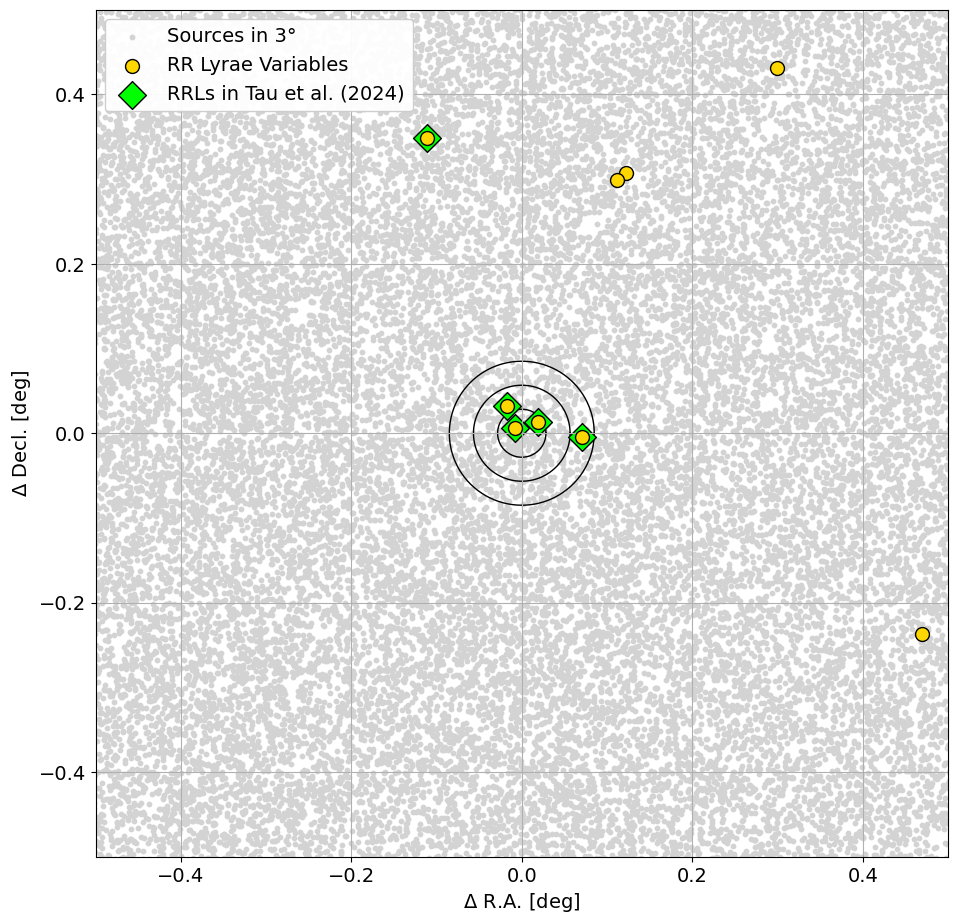

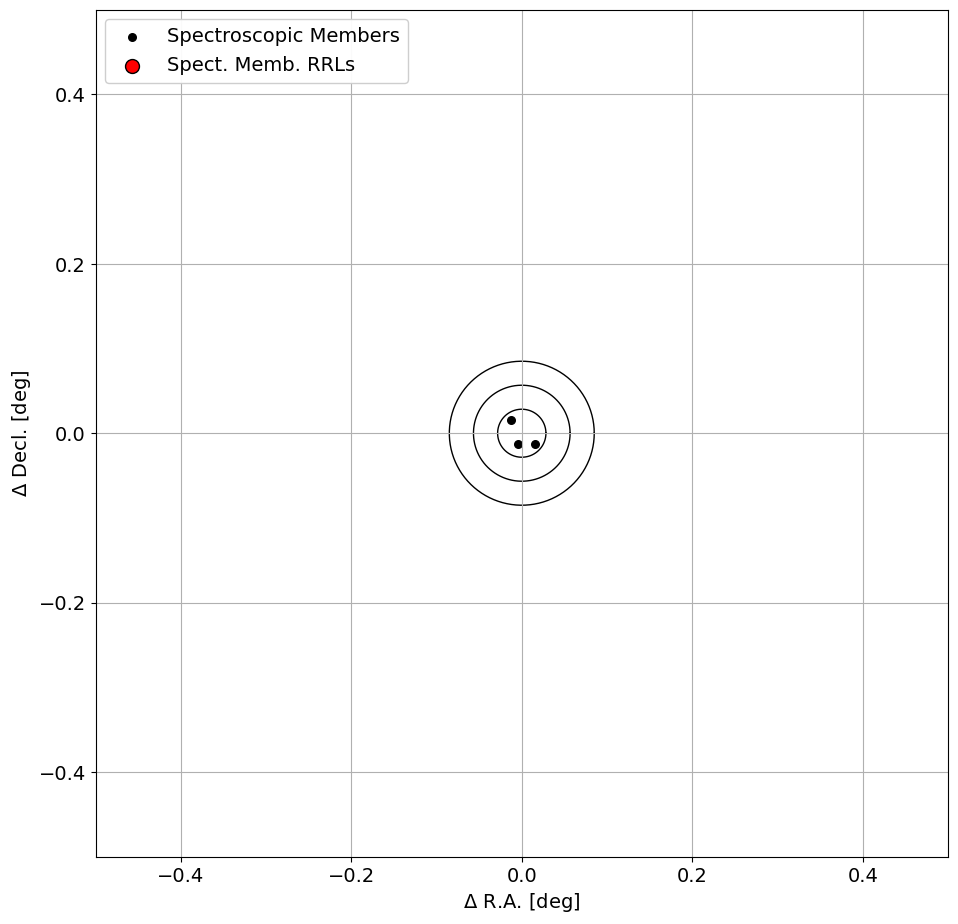

In [14]:
## Zoom in

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(11,11))
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data['ra'] - center[0], data['dec'] - center[1], s=10, marker='o', c='lightgrey', label='Sources in 3°', zorder=0)
plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
#plt.scatter(add_class_rr['ra'] - center[0], add_class_rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='blue', linewidth=3, label='Gaia DR3 vari_classifier_result', zorder=2)
plt.scatter(tau['ra'] - center[0], tau['dec'] - center[1], s=200, marker='D', c='lime', edgecolor='k', label='RRLs in Tau et al. (2024)', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/SagittariusII/SagittariusII_initial_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


# Spectroscopic Members

plt.figure(figsize=(11,11))
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=30, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/SagittariusII/SagittariusII_memb_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Colormap of RR Lyrae based on 'int_average_g'

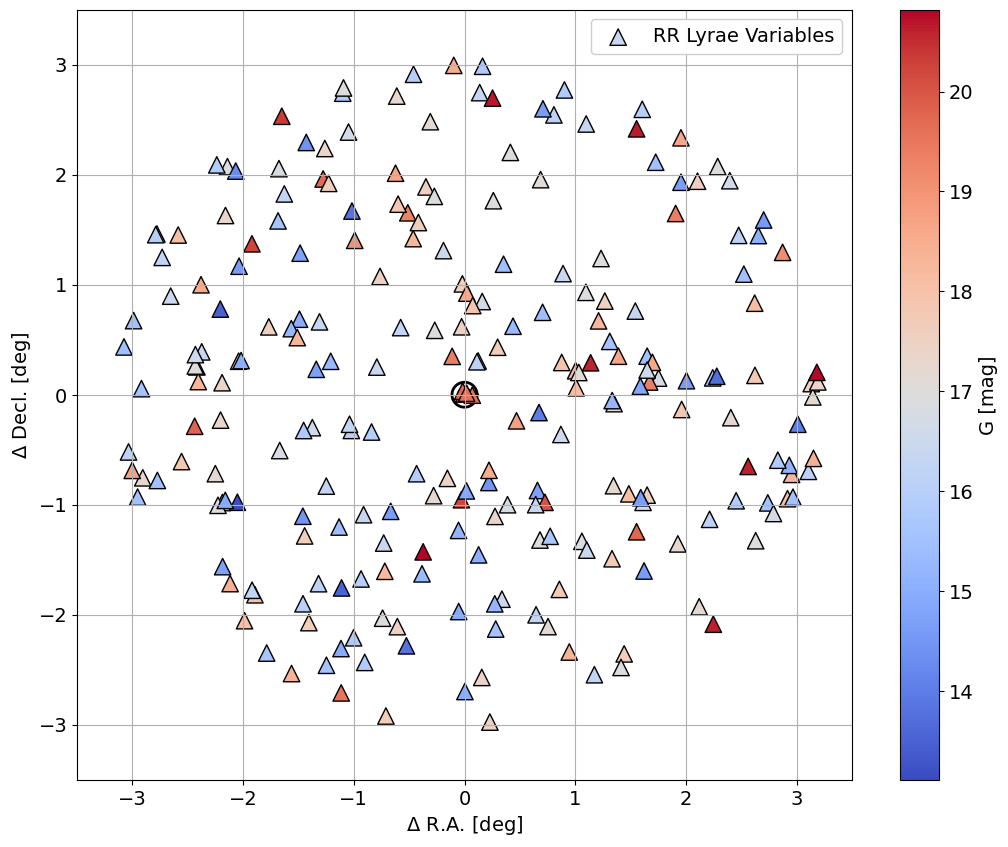

In [15]:
plt.figure(figsize=(12.5,10))
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], c=rr['int_average_g'], cmap='coolwarm', s=140, marker='^', edgecolor='k', label='RR Lyrae Variables', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=2, zorder=0)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
cbar.set_label('G [mag]', fontsize=14)
plt.savefig('Plot/SagittariusII/SagittariusII_colormap.png', bbox_inches='tight', pad_inches=0)
plt.show()

## RR Lyrae selection through Proper Motions + PWZ

### Proper Motions

#### Errors on Proper Motions ([Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657), table 3): comparison with Spectroscopic Members

This removal was not applied to Sagittarius II RRLs since they are expected be too faint, so affected by great uncertainties.

In [16]:
# Cut at pm_error = 0.5

print('Initial RR Lyrae: ', len(rr))

mask_pm05 = ((rr['pmra_error'] < 0.5) | (rr['pmdec_error'] < 0.5))
pm05 = rr[mask_pm05]

print('RR Lyrae with pmra_error and pmdec_error < 0.5: ', len(pm05))

if len(pm05) < len(rr) :
    print(str(len(rr) - len(pm05)) + ' RR Lyrae removed:')
    print(rr[~mask_pm05]['source_id'])

#rr[~mask_pm05].to_csv('Output/SagittariusII/SagittariusII_pmerr05.csv', index=False)

Initial RR Lyrae:  243
RR Lyrae with pmra_error and pmdec_error < 0.5:  232
11 RR Lyrae removed:
19     6863806069172589312
53     6863916741889551104
59     6852167257554468608
62     6851364781571790208
99     6852036965426508544
103    6853734473941355776
125    6867243348678242944
131    6868187137676241408
135    6866986578353579520
145    6868879387624872576
213    6864490102841222784
Name: source_id, dtype: int64


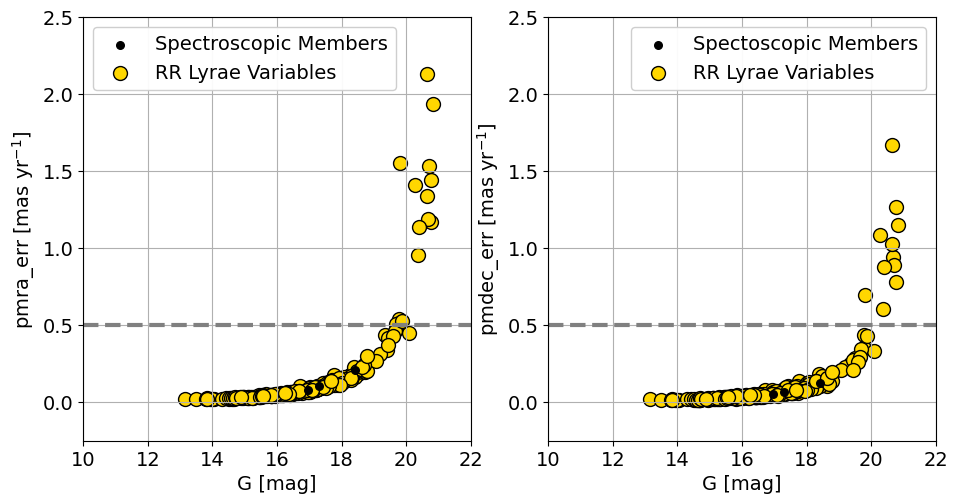

In [17]:
## PM ERRORS

pm1, (pmraerr1, pmdecerr1) = plt.subplots(1, 2, figsize=(11,5.5))

# PM RA with Spectroscopic Members

pmraerr1.set_xlim(10,22)
pmraerr1.set_ylim(-0.25,2.5)
pmraerr1.tick_params(labelsize=14)
pmraerr1.set_xlabel('G [mag]', fontsize=14)
pmraerr1.set_ylabel(r'pmra_err [mas yr$^{-1}$]', fontsize=14)
pmraerr1.scatter(memb['phot_g_mean_mag'], memb['pmra_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectroscopic Members', zorder=2)
pmraerr1.scatter(rr['phot_g_mean_mag'], rr['pmra_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=1)
pmraerr1.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')
pmraerr1.legend(loc=0, fontsize=14, framealpha=0.95)
pmraerr1.grid(True)

## PM DEC with Spectroscopic Members

pmdecerr1.set_xlim(10,22)
pmdecerr1.set_ylim(-0.25,2.5)
pmdecerr1.tick_params(labelsize=14)
pmdecerr1.set_xlabel('G [mag]', fontsize=14)
pmdecerr1.set_ylabel(r'pmdec_err [mas yr$^{-1}$]', fontsize=14)
pmdecerr1.scatter(memb['phot_g_mean_mag'], memb['pmdec_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectoscopic Members', zorder=2)
pmdecerr1.scatter(rr['phot_g_mean_mag'], rr['pmdec_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=1)
pmdecerr1.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')
pmdecerr1.legend(loc=0, fontsize=14, framealpha=0.95)
pmdecerr1.grid(True)

plt.savefig('Plot/SagittariusII/SagittariusII_pmerr.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


#### Histograms

In [18]:
## Gaussian of Data

mask3 = ((data_2rh['pmra'] > -20) & (data_2rh['pmra'] < 20) & (data_2rh['pmdec'] > -20) & (data_2rh['pmdec'] < 20))
data_mask3 = data_2rh[mask3]

mu_ra, std_ra = norm.fit(data_mask3['pmra'])
mu_dec, std_dec = norm.fit(data_mask3['pmdec'])

x = np.linspace(-50, 50, 1000)
p_ra = norm.pdf(x, mu_ra, std_ra)
p_dec = norm.pdf(x, mu_dec, std_dec)


## Gaussian of RR Lyrae in 3°

mu_rr_ra, std_rr_ra = norm.fit(rr['pmra'])
mu_rr_dec, std_rr_dec = norm.fit(rr['pmdec'])

x_rr = np.linspace(-50, 50, 1000)
p_rr_ra = norm.pdf(x_rr, mu_rr_ra, std_rr_ra)
p_rr_dec = norm.pdf(x_rr, mu_rr_dec, std_rr_dec)


## Gaussian of Sectroscopic Members

memb_mask = memb

mu_memb_ra, std_memb_ra = norm.fit(memb_mask['pmra'])
mu_memb_dec, std_memb_dec = norm.fit(memb_mask['pmdec'])

x_memb = np.linspace(-20, 20, 1000)
p_memb_ra = norm.pdf(x_memb, mu_memb_ra, std_memb_ra)
p_memb_dec = norm.pdf(x_memb, mu_memb_dec, std_memb_dec)


## Proper Motion centers

center_mymemb = np.array(object=(mu_memb_ra, mu_memb_dec))
err_mymemb = np.array(object=(std_memb_ra, std_memb_dec))

In [19]:
array = {'name': ['sources_ra', 'sources_dec', 'rr_ra', 'rr_dec', 'memb_ra', 'memb_dec'],
         'mu': [mu_ra, mu_dec, mu_rr_ra, mu_rr_dec, mu_memb_ra, mu_memb_dec],
         'std': [std_ra, std_dec, std_rr_ra, std_rr_dec, std_memb_ra, std_memb_dec]}

array_mu_std = pd.DataFrame(array)

print(array_mu_std)

array_mu_std.to_csv('Output/SagittariusII/SagittariusII_mu_std.csv', index=False)

          name        mu       std
0   sources_ra -0.595134  4.255482
1  sources_dec -4.489911  4.454528
2        rr_ra -0.971856  3.629305
3       rr_dec -4.264879  3.862974
4      memb_ra -0.797993  0.066665
5     memb_dec -0.922684  0.012072


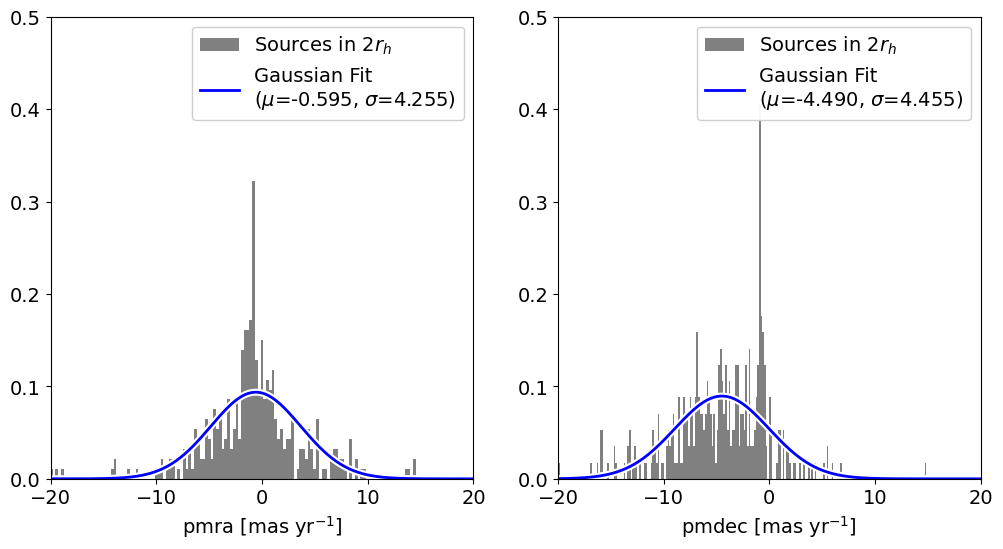

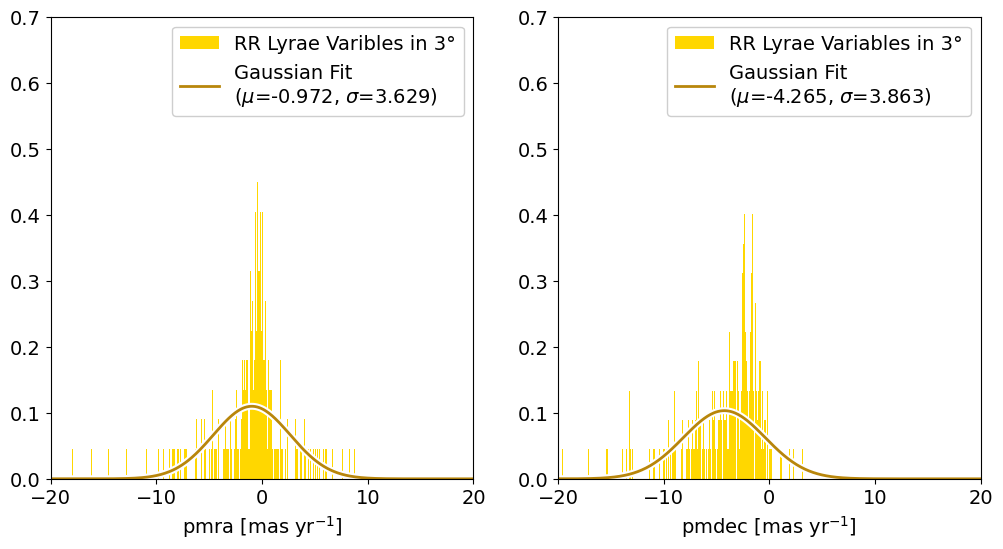

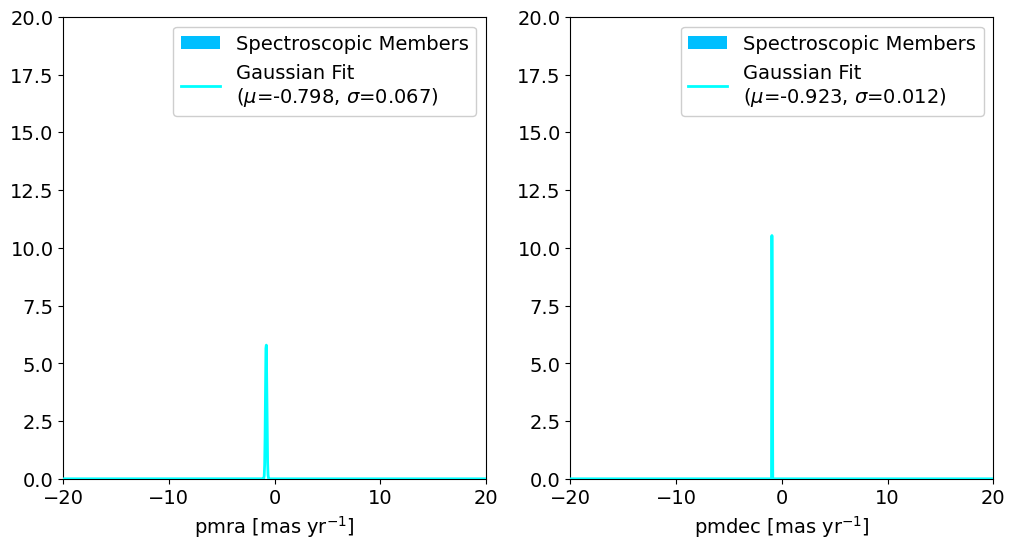

In [20]:
## Histograms

# Sources in 2*r_h

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,0.5)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(data_2rh['pmra'], bins=len(data_2rh), density=True, label=r'Sources in 2$r_h$', color='grey')
pmra1.plot(x, p_ra, c='white', linewidth=5)
pmra1.plot(x, p_ra, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_ra) + ', $\sigma$=' + '{:.3f}'.format(std_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,0.5)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(data_2rh['pmdec'], bins=len(data_2rh), density=True, label=r'Sources in 2$r_h$', color='grey')
pmdec1.plot(x, p_dec, c='white', linewidth=5)
pmdec1.plot(x, p_dec, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_dec) + ', $\sigma$=' + '{:.3f}'.format(std_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)
plt.savefig('Plot/SagittariusII/SagittariusII_pm_sources.png', bbox_inches='tight', pad_inches=0)
plt.show()


# RR Lyrae in 3°

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,0.7)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(rr['pmra'], bins=len(rr)+50, density=True, label=r'RR Lyrae Varibles in 3°', color='gold')
pmra1.plot(x_rr, p_rr_ra, c='white', linewidth=5)
pmra1.plot(x_rr, p_rr_ra, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_ra) + ', $\sigma$=' + '{:.3f}'.format(std_rr_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,0.7)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(rr['pmdec'], bins=len(rr)+50, density=True, label=r'RR Lyrae Variables in 3°', color='gold')
pmdec1.plot(x_rr, p_rr_dec, c='white', linewidth=5)
pmdec1.plot(x_rr, p_rr_dec, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_dec) + ', $\sigma$=' + '{:.3f}'.format(std_rr_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/SagittariusII/SagittariusII_pm_rr.png', bbox_inches='tight', pad_inches=0)
plt.show()


# With Spectroscopic Members

pm2, (pmra2, pmdec2) = plt.subplots(1, 2, figsize=(12,6))

pmra2.set_xlim(-20,20)
pmra2.set_ylim(0,20)
pmra2.tick_params(labelsize=14)
pmra2.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra2.hist(memb['pmra'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmra2.plot(x_memb, p_memb_ra, c='white', linewidth=5)
pmra2.plot(x_memb, p_memb_ra, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_ra) + ', $\sigma$=' + '{:.3f}'.format(std_memb_ra) + ')', zorder=3)
pmra2.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec2.set_xlim(-20,20)
pmdec2.set_ylim(0,20)
pmdec2.tick_params(labelsize=14)
pmdec2.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec2.hist(memb['pmdec'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmdec2.plot(x_memb, p_memb_dec, c='white', linewidth=5)
pmdec2.plot(x_memb, p_memb_dec, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_dec) + ', $\sigma$=' + '{:.3f}'.format(std_memb_dec) + ')', zorder=3)
pmdec2.legend(loc=1, fontsize=14, framealpha=0.95)
plt.savefig('Plot/SagittariusII/SagittariusII_pm_memb.png', bbox_inches='tight', pad_inches=0)
plt.show()

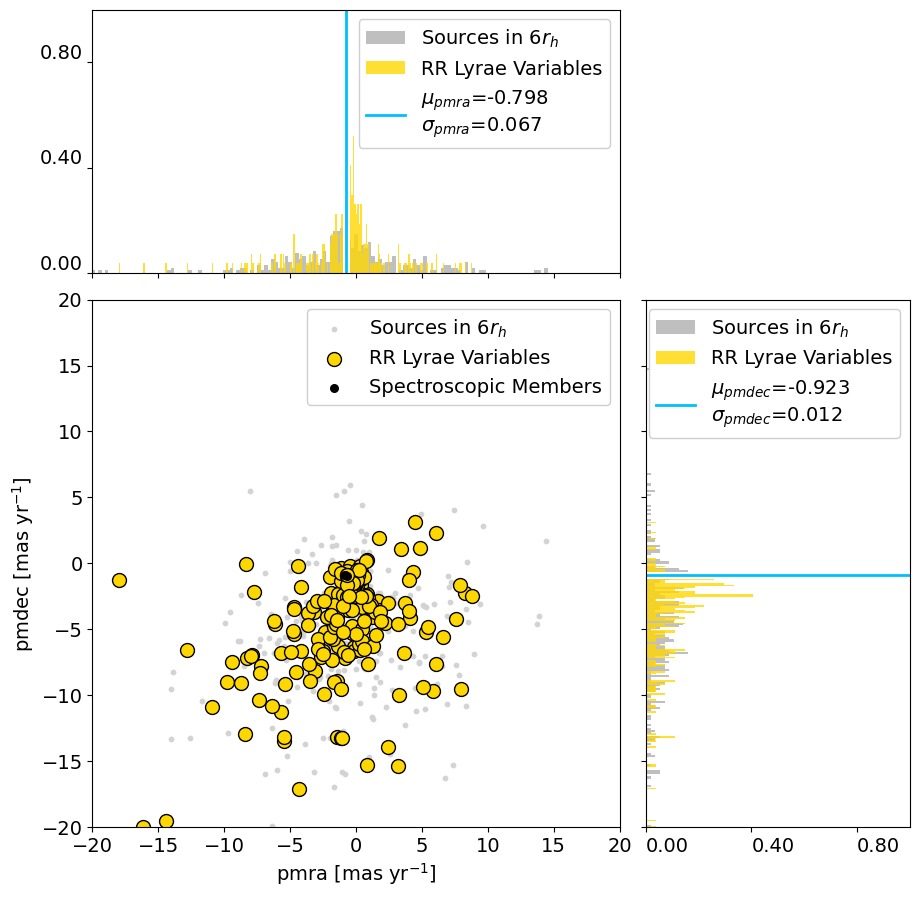

In [21]:
## PM

pm3 = plt.figure(layout='tight', figsize=(11,11))
ax3 = pm3.add_subplot()

ax3.set_aspect('equal')

ax3_histx = ax3.inset_axes([0, 1.05, 1, 0.5], sharex=ax3)
ax3_histy = ax3.inset_axes([1.05, 0, 0.5, 1], sharey=ax3)

scatter_hist(data_2rh['pmra'], data_2rh['pmdec'], rr['pmra'], rr['pmdec'], ax3, ax3_histx, ax3_histy, center_mymemb, err_mymemb)

ax3.scatter(memb['pmra'], memb['pmdec'], s=30, color='black', edgecolor='k', label='Spectroscopic Members', zorder=5)

ax3.legend(loc=1, fontsize=14, framealpha=0.95)

plt.setp(ax3_histy.get_xticklabels(), ha='left')
plt.setp(ax3_histx.get_yticklabels(), va='bottom')

plt.savefig('Plot/SagittariusII/SagittariusII_paper01.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


### Sources within 3$\sigma$ of mean proper motions (w.r.t. Spectroscopic Members)

In [22]:
## Sources in 3°

mask4 = (data['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_final = data[mask4]

mask4 = (data_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_final = data_final[mask4]

print('Sources within 3sigma of mean proper motions in 3°: ' + str(len(data_final)))


## Sources in 2*r_h

mask4 = (data_2rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_2rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_2rh_final = data_2rh[mask4]

mask4 = (data_2rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_2rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_2rh_final = data_2rh_final[mask4]

print('Sources within 3sigma of mean proper motions in 2r_h: ' + str(len(data_2rh_final)))


## RR Lyrae in 3°

mask5 = (rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_final = rr[mask5]

mask5 = (rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_final = rr_final[mask5]

print('RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(rr_final)))


## RR Lyrae in 2*r_h

mask6 = (rr_2rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr_2rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_2rh_final = rr_2rh[mask6]

mask6 = (rr_2rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_2rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_2rh_final = rr_2rh_final[mask6]

print('RR Lyrae within 3sigma of mean proper motions in 2r_h: ' + str(len(rr_2rh_final)))


## RR Lyrae Classified in 3°

mask7 = (add_class_rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (add_class_rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

add_class_rr_final = add_class_rr[mask7]

mask7 = (add_class_rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (add_class_rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

add_class_rr_final = add_class_rr_final[mask7]

print('Classified RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(add_class_rr_final)))

Sources within 3sigma of mean proper motions in 3°: 191
Sources within 3sigma of mean proper motions in 2r_h: 8
RR Lyrae within 3sigma of mean proper motions in 3°: 2
RR Lyrae within 3sigma of mean proper motions in 2r_h: 1
Classified RR Lyrae within 3sigma of mean proper motions in 3°: 0


In [23]:
## Sgr Stream cut in PM

print('Sgr Stream RRLy: ' + str(len(data_sgr)))

mask7a = (data_sgr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_sgr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_sgr_pmcut = data_sgr[mask7a]

mask7a = (data_sgr_pmcut['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_sgr_pmcut['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_sgr_pmcut = data_sgr_pmcut[mask7a]

print('Sgr Stream RRLy within 3sigma of mean proper motions in 3°: ' + str(len(data_sgr_pmcut)))

Sgr Stream RRLy: 3
Sgr Stream RRLy within 3sigma of mean proper motions in 3°: 0


### Period-Wesenheit-Metallicity Relation

In [24]:
w_mag_final = wesen(rr_final['int_average_g'], rr_final['phot_bp_mean_mag'], rr_final['phot_rp_mean_mag'])
w_mag_error_final = wesen_err(rr_final['int_average_g_error'], rr_final['phot_bp_mean_mag_error'], rr_final['phot_rp_mean_mag_error'])
w_mag_tau = wesen(tau_rr['int_average_g'], tau_rr['phot_bp_mean_mag'], tau_rr['phot_rp_mean_mag'])


## Garofalo et al. 2022: intrinsic dispersion of 0.09 ± 0.01 mag

w_sigma = 0.09


## Period

period_final = np.log10(rr_final['pf'])
period_final[np.isnan(period_final)] = np.log10(rr_final['p1_o'][np.isnan(period_final)]) + 0.127


## Info. from Vivas et al. 2020

# Distance Module

mu0 = float(- 5 + 5 * np.log10(vivas['distance'] * 1000.0))

print('Distance Module: ' + str(mu0))


# Iron Abundance

fe = float(vivas['fe_h'])

print('Iron Abundance: ' + str(fe))


## General Wesenheit Relation

pw_line_final = pw(period_final, fe, mu0)

# Generic only for plot

t = np.linspace(-0.5, 0, 100)
pw_generic = pw(t, fe, mu0)


## RR Lyrae in 3sigma of PW

rr_pw_final = rr_final.copy()
rr_pw_final.insert(len(rr_pw_final.columns), 'w_mag', w_mag_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'w_period', period_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'pw_line', pw_line_final)

mask_pw_final = ((w_mag_final <= pw_line_final + 3*w_sigma) & (w_mag_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final + w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final + w_mag_error_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final - w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final - w_mag_error_final >= pw_line_final - 3*w_sigma))

rr_pw_final = rr_pw_final[mask_pw_final]

print('RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(rr_pw_final)))

Distance Module: 19.319586884789302
Iron Abundance: -2.28
RR Lyrae within 3sigma of Wesenheit Relation: 1


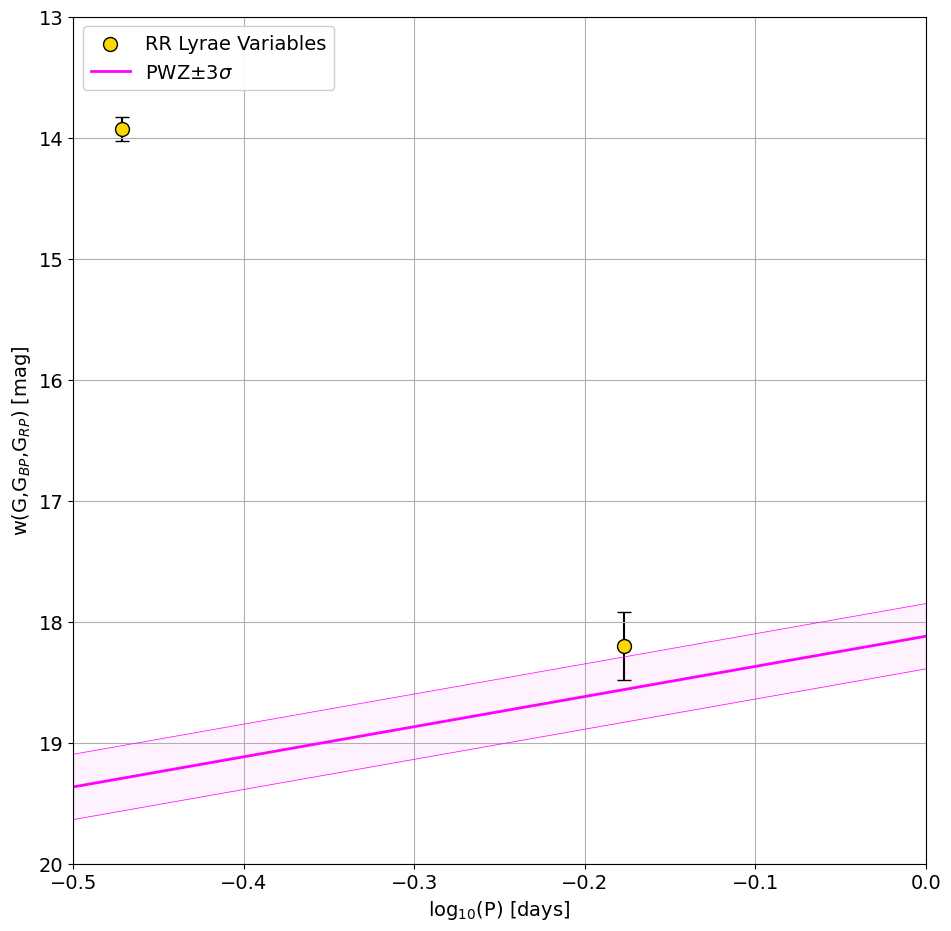

In [25]:
## PWZ

plt.figure(figsize=(11,11))
plt.xlim(-0.5,0)
plt.ylim(20,13)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'log$_{10}$(P) [days]', fontsize=14)
plt.ylabel(r'w(G,G$_{BP}$,G$_{RP}$) [mag]', fontsize=14)


## All RR Lyrae

plt.scatter(np.log10(rr_final['pf']), w_mag_final, c='gold', edgecolor='k', marker='o', s=100, label='RR Lyrae Variables', zorder=1)
plt.scatter(np.log10(rr_final['p1_o'])+0.127, w_mag_final, c='gold', edgecolor='k', marker='o', s=100, zorder=1) # Fundamentalisation
plt.errorbar(np.log10(rr_final['pf']), w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(rr_final['p1_o'])+0.127, w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)

## Intrinsic dispersion

plt.plot(t, pw_generic, c='magenta', linewidth=2, label=r'PWZ$\pm 3 \sigma$', linestyle = 'solid')
plt.plot(t, pw_generic + 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.plot(t, pw_generic - 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.fill_between(t, pw_generic + 3*w_sigma, pw_generic - 3*w_sigma, alpha=0.05, color='magenta', zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/SagittariusII/SagittariusII_pwz.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Color-Magnitude Diagram

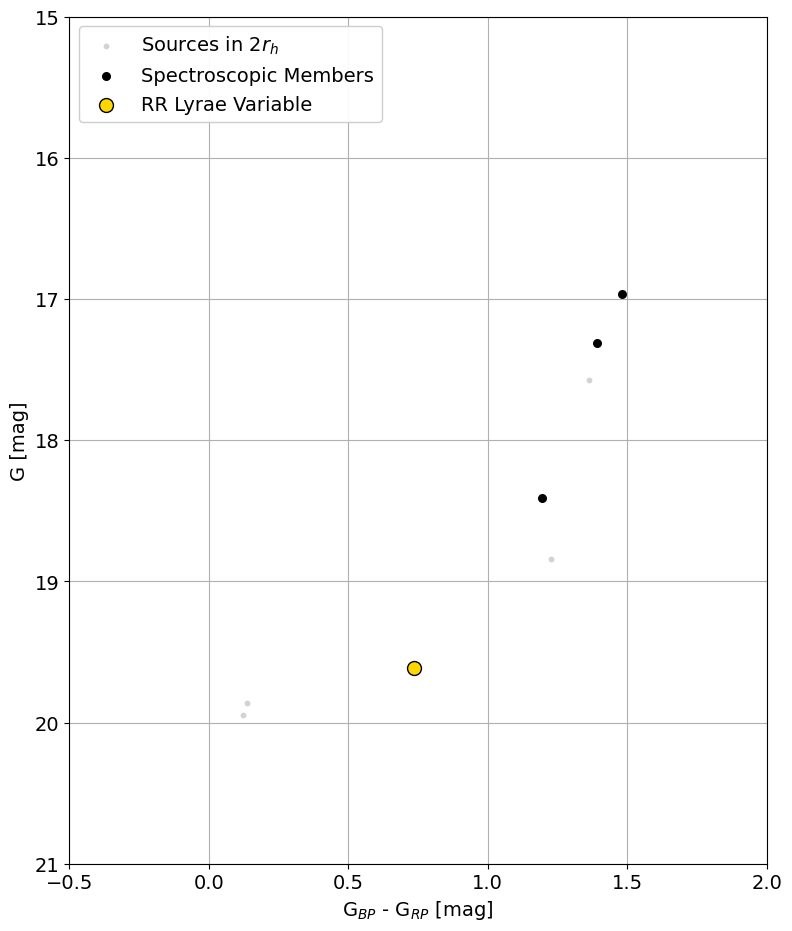

In [26]:
## CMD

plt.figure(figsize=(9,11))
plt.xlim(-0.5,2)
plt.ylim(21,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'G$_{BP}$ - G$_{RP}$ [mag]', fontsize=14)
plt.ylabel('G [mag]', fontsize=14)

plt.scatter(data_2rh_final['phot_bp_mean_mag'] - data_2rh_final['phot_rp_mean_mag'], data_2rh_final['phot_g_mean_mag'], s=10, c='lightgrey', marker='o', label=r'Sources in 2$r_h$', zorder=0)
plt.scatter(memb['phot_bp_mean_mag'] - memb['phot_rp_mean_mag'], memb['phot_g_mean_mag'], s=30, marker='o', c='k', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(rr_pw_final['phot_bp_mean_mag'] - rr_pw_final['phot_rp_mean_mag'], rr_pw_final['int_average_g'], s=100, marker='o', edgecolor='k', color='gold', label=r'RR Lyrae Variable', zorder=2)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/SagittariusII/SagittariusII_paper02.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


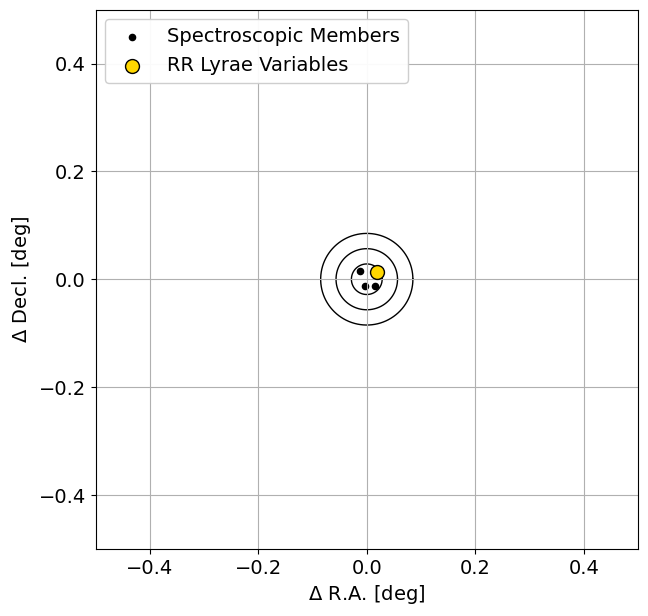

In [27]:
## Final map

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(7,7))
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=20, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(rr_pw_final['ra']- center[0], rr_pw_final['dec']- center[1], s=100, marker='o', c='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/SagittariusII/SagittariusII_final_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

## File saving

In [28]:
# RR Lyrae in 3° after PM cut
#rr_final.to_csv('Output/SagittariusII/SagittariusII_rr_final.csv', index=False)

# Final 1 RRL in Sagittarius II
print('Final member RR Lyrae: ' + str(len(rr_pw_final)))
rr_pw_final.to_csv('Output/SagittariusII/SagittariusII_rr_final.csv', index=False)

Final member RR Lyrae: 1


## Conclusions
- After Proper Motion and PWZ selections we found only 1 RRLs, from vari_rrlyrae 
- There are four RRd in Sagittarius II, but they do not pass the selections